### Utilidades

In [37]:
import sys
import os
# Add the project root to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [72]:
from utils.read_json import read_object

In [74]:
tool_path = '../tools/citas_json.json'

servicios = read_object(tool_path,'services')
profesionales = read_object(tool_path,'professionals')
horarios = read_object(tool_path,'schedules')

In [40]:
def get_service_names(services):
    """Extract all the service_names"""
    service_names = [service['service_name'] for service in services]
    return service_names

print(get_service_names(servicios))

['Consulta Medica', 'Odontologia', 'Medicina Interna', 'Pediatría']


In [41]:
def get_professionals_by_service(service_name: str):
    """Extract the professionals by service"""

    # Find the service that matches the service_name
    matching_services = [service for service in servicios if service_name in service['service_name']]
    
    # Extract professional IDs from matching services and flatten the list
    professional_ids = []
    for service in matching_services:
        professional_ids.extend(service['professionals'])

    # Get professional info for the matching IDs
    professional_info = [professional['personal_info'] for professional in profesionales if professional['_id'] in professional_ids]
    
    return professional_info

print(get_professionals_by_service('Consulta Medica'))

[{'name': 'Medico 1', 'specialty': 'Medicina General'}, {'name': 'Medico 2', 'specialty': 'Medicina General'}]


In [83]:
def get_schedules_by_professional_name(professional_name: str):
    """Extract the schedules by the selected professional"""
    schedule = []
    for horario in horarios:
        if horario['professional_name'] in professional_name:
            schedule.extend(horario['daily_schedules'])
    return schedule

print(get_schedules_by_professional_name('Medico 2'))  

[{'date': '2024-07-18', 'time': '08:00', 'is_available': True}, {'date': '2024-07-19', 'time': '08:00', 'is_available': True}, {'date': '2024-07-22', 'time': '08:00', 'is_available': True}]


### Definición de Nodos

In [47]:
from typing import TypedDict, Optional
from datetime import datetime
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Define the state of the agent

class State(TypedDict):
    user_name: str
    message: str
    role: str
    fecha: Optional[datetime]
    servicio: Optional[str]
    medico: Optional[str]
    availability: Optional[bool]

In [48]:
def node_1(state: State) -> State:
    state["user_name"] = "John"
    state["message"] = "Hola, necesito agendar una cita"
    state["role"] = "user"
    return state

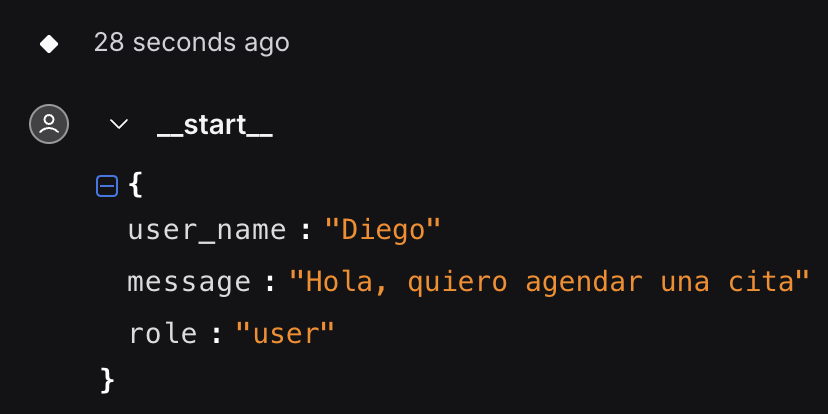

In [88]:
display(Image('images/n1.png'))

In [60]:
# Tool retorna los nombres de los servicios
def node_2(state: State) -> State:
    user_name = state["user_name"]
    state["message"] = f"Hola {user_name} seleccione el tipo de servicio: {get_service_names(servicios)}"
    state["role"] = "bot"
    return state

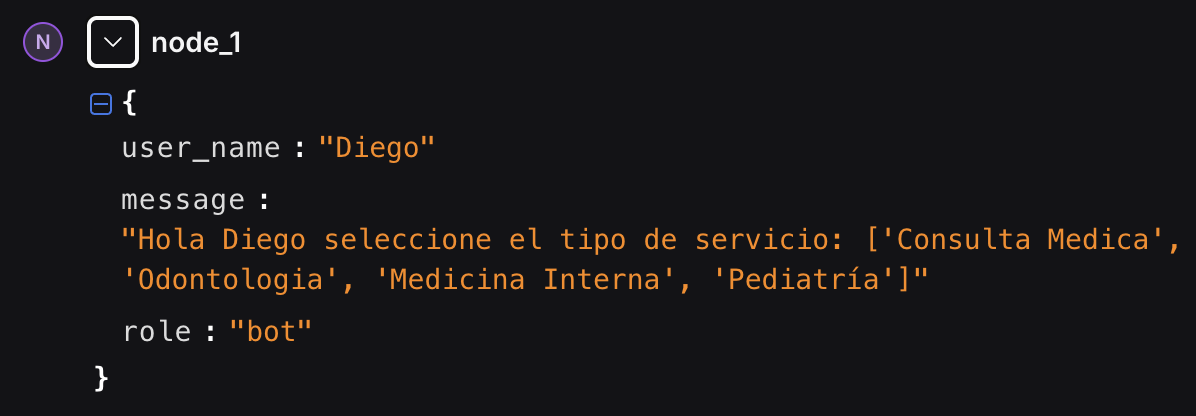

In [89]:
display(Image('images/n2.png'))

In [61]:
def node_3(state: State) -> State:
    state["message"] = "Quiero agendar una consulta medica"
    state["role"] = "user"
    return state

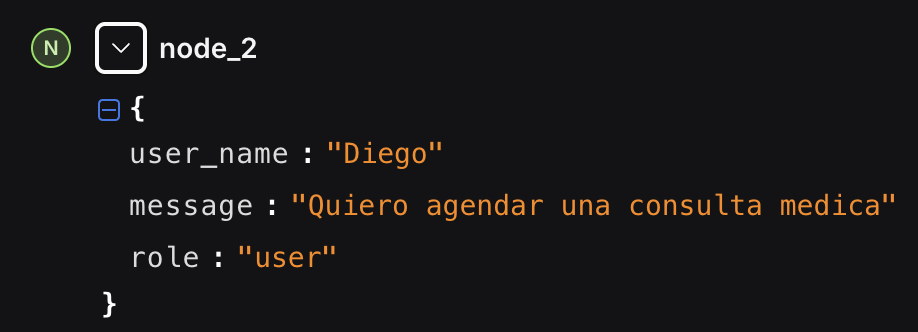

In [90]:
display(Image('images/n3.png'))

In [62]:
# Dependiendo de la selección anterior, selecciona el médico
def node_4(state: State) -> State:
    state["servicio"] = "Consulta Medica"
    nombre_servicio = state["servicio"]
    state["message"] = f"Con que médico?: {get_professionals_by_service(nombre_servicio)}"
    state["role"] = "bot"
    return state

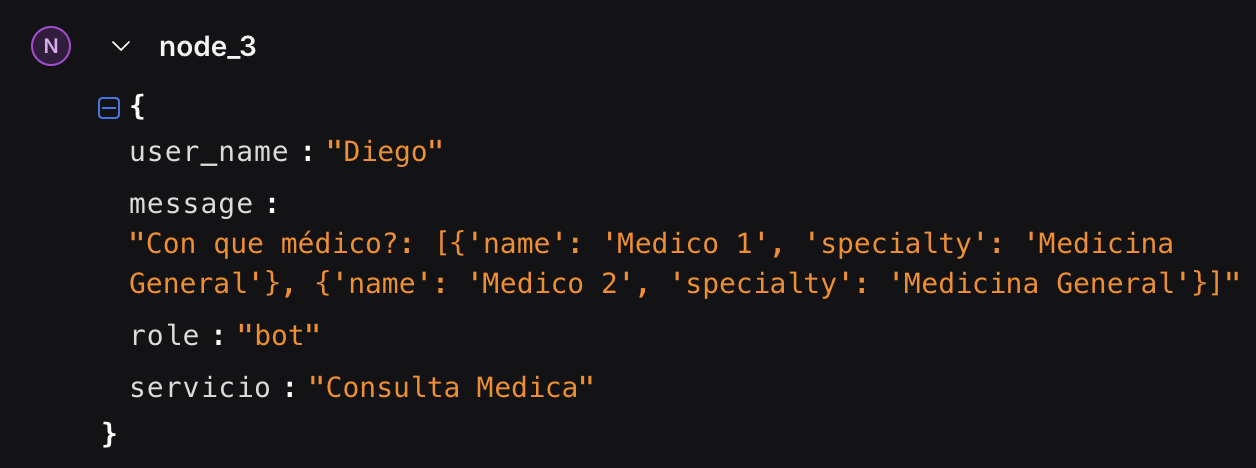

In [91]:
display(Image('images/n4.png'))

In [63]:
def node_5(state: State) -> State:
    state["message"] = "Con el Medico 1 por favor"
    state["role"] = "user"
    return state

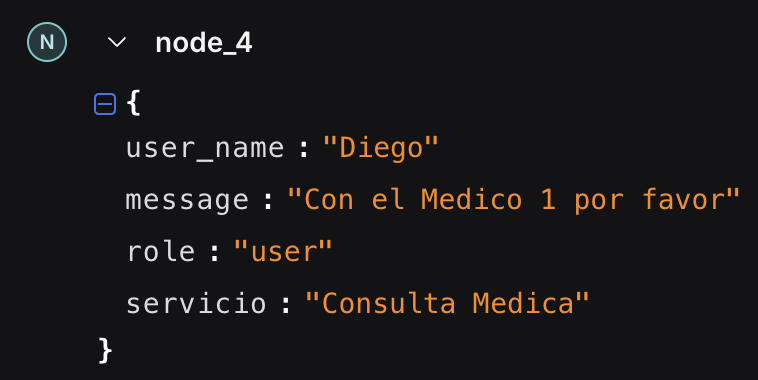

In [92]:
display(Image('images/n5.png'))

In [67]:
def node_6(state: State) -> State:
    state["profesional_name"] = "Medico 1"
    professional_name = state["profesional_name"]
    state["message"] = f"Con el médico {professional_name} tenemos los siguientes horarios: {get_schedules_by_professional_name(professional_name)}"
    state["role"] = "bot" 
    return state

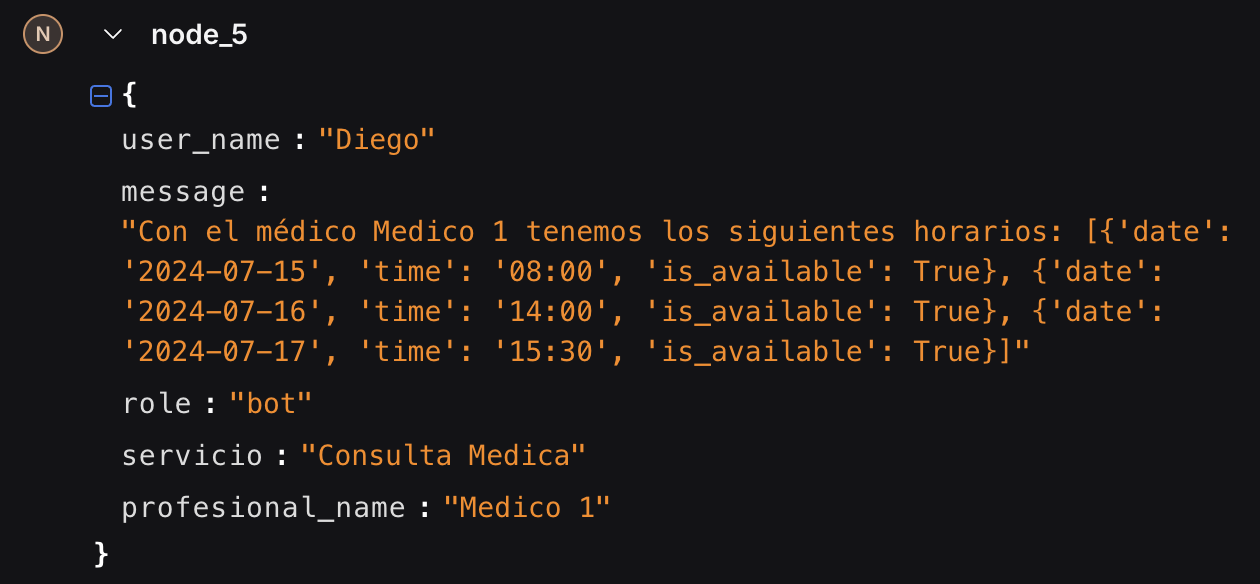

In [93]:
display(Image('images/n6.png'))

In [68]:
def node_7(state: State) -> State:
    state["message"] = "La cita sería para el día jueves 10 de julio a las 8"
    state["role"] = "user"
    return state

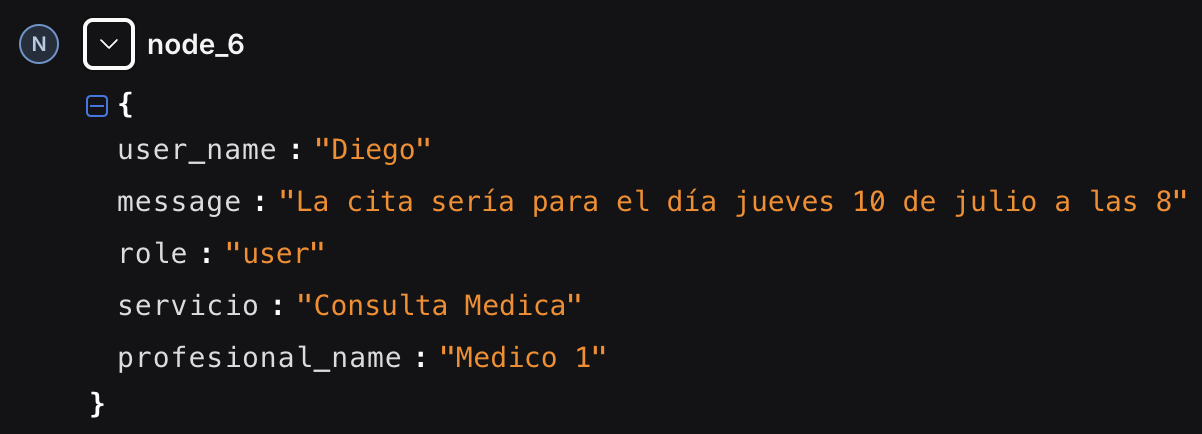

In [94]:
display(Image('images/n7.png'))

In [85]:
def node_8(state: State) -> State:
    state["fecha"] = datetime(2025,7,10,8)
    state["available"] = True
    state["role"] = "bot"

    fecha = state["fecha"]
    available = state["available"]
    servicio = state["servicio"]
    professional_name = state["profesional_name"]

    if available:
        message = f"La cita de tipo {servicio} será agendada para la fecha {fecha} con el doctor {professional_name} desea confirmar?"
    else:
        message = "Seleccione otro día"

    return {
        "message": message,
        "role": state["role"]
    }

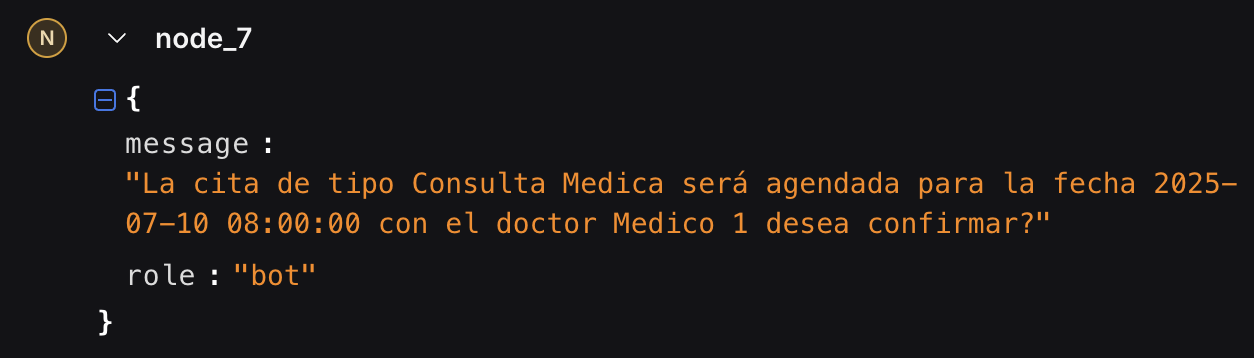

In [95]:
display(Image('images/n8.png'))

### Definición del Graph (Conjunto de nodos)

In [ ]:
builder = StateGraph(State)

builder.add_node('node_1', node_1)
builder.add_node('node_2', node_2)
builder.add_node('node_3', node_3)
builder.add_node('node_4', node_4)
builder.add_node('node_5', node_5)
builder.add_node('node_6', node_6)
builder.add_node('node_7', node_7)
builder.add_node('node_8', node_8)

builder.add_edge(START, 'node_1')
builder.add_edge('node_1', 'node_2')
builder.add_edge('node_2', 'node_3')
builder.add_edge('node_3', 'node_4')
builder.add_edge('node_4', 'node_5')
builder.add_edge('node_5', 'node_6')
builder.add_edge('node_6', 'node_7')
builder.add_edge('node_7', 'node_8')
builder.add_edge('node_8', END)

graph = builder.compile()

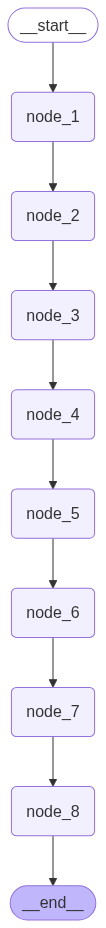

In [87]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))